### Гипотеза 4:  Использование больше эпох и Early Stopping для улучшения качества моделей

Импорт библиотек и загрузка результатов экспериментов для сравнения гипотез.

In [ ]:
from common import *
all_results = load_results()

Загрузка параметров обучения и подготовка датасетов с загрузчиками

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка сплитов и подготовки параметров
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
SEED = cfg["seed"] # seed для воспроизводимости
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы изображений для тренировочного набора
val_indices = cfg["val_indices"] # индексы изображений для валидационного набора

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание тестового набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # получение изображений для тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # получение изображений для валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора    
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


Функция обучения с CosineAnnealing

In [ ]:
def train_model_es(model, model_name, train_loader, val_loader, test_loader, epochs=20, lr=1e-3, patience=3, device=DEVICE):
    """ Обучение модели с использованием Early Stopping """  
    set_seed(SEED)
    model = model.to(device) # перенос модели на устройство
    criterion = nn.CrossEntropyLoss() # функция потерь
    optimizer = optim.Adam(model.parameters(), lr=lr) # оптимизатор
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) # scheduler

    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None # масштабирование градиентов

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # словарь для хранения истории обучения
    best_val_loss = float('inf') # лучшие потери на валидации
    patience_counter = 0 # счетчик терпения
    best_model_wts = None # лучшие веса модели

    for epoch in range(epochs): # проход по всем эпохам
        model.train() # перевод модели в режим обучения
        running_loss = 0.0 # счетчик потерь
        all_preds = [] # список предсказаний
        all_labels = [] # список меток

        for images, labels in train_loader: # проход по всем изображениям и меткам
            images, labels = images.to(device), labels.to(device) # перенос изображений и меток на устройство
            optimizer.zero_grad() # обнуление градиентов

            if scaler: # если масштабирование градиентов включено   
                with torch.amp.autocast('cuda'): # включение автоматического масштабирования градиентов
                    outputs = model(images) # получение предсказаний
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # масштабирование градиентов
                scaler.step(optimizer)
                scaler.update()
            else: # если масштабирование градиентов не включено
                outputs = model(images) # получение предсказаний
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратная связь
                optimizer.step() # обновление весов
            
            running_loss += loss.item() * images.size(0) # суммирование потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        
        train_loss = running_loss / len(train_loader.dataset) # вычисление потерь на тренировочном наборе
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности на тренировочном наборе

        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # вычисление потерь, точности, балансированной точности, F1-меры на валидационном наборе
        scheduler.step() # обновление scheduler

        history["train_loss"].append(train_loss) # добавление потерь на тренировочном наборе в словарь
        history["val_loss"].append(val_loss) # добавление потерь на валидационном наборе в словарь
        history["train_acc"].append(train_acc) # добавление точности на тренировочном наборе в словарь
        history["val_acc"].append(val_acc) # добавление точности на валидационном наборе в словарь

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

        # проверка на раннюю остановку
        if val_loss < best_val_loss:
            best_val_loss = val_loss # обновление лучших потерь на валидационном наборе
            patience_counter = 0 # сброс счетчика терпения
            best_model_wts = {k: v.clone() for k, v in model.state_dict().items()} # сохранение лучших весов модели
        else: # если потери на валидационном наборе не улучшились
            patience_counter += 1 # увеличение счетчика терпения
            if patience_counter >= patience: # если счетчик терпения превысил заданное значение
                print(f"Early stopping at epoch {epoch+1}") # вывод сообщения о ранней остановке
                break

    if best_model_wts is not None: # если лучшие веса модели найдены
        model.load_state_dict(best_model_wts) # загрузка лучших весов модели

    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    ) # вычисление потерь, точности, балансированной точности, F1-меры на тестовом наборе

    # вывод метрик на тестовом наборе
    print(f"\n{model_name} -  TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # построение матрицы путаницы
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # графики потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # отчёт о классификации
    print(f"{model_name} - Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение результатов
    return {
        "model": model_name,
        "test_acc": test_acc,
        "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1,
        "history": history,
        "confusion_matrix": cm.tolist(),
    }

Обучение модели ResNet18 с большим количеством эпох и Early Stopping

Epoch 1/20 - Train Loss: 0.2810, Train Acc: 0.8903, Val Loss: 0.3798, Val Acc: 0.8725, Val Bal Acc: 0.8724, Val F1: 0.8723
Epoch 2/20 - Train Loss: 0.0882, Train Acc: 0.9682, Val Loss: 0.1611, Val Acc: 0.9503, Val Bal Acc: 0.9505, Val F1: 0.9497
Epoch 3/20 - Train Loss: 0.0848, Train Acc: 0.9706, Val Loss: 0.0513, Val Acc: 0.9809, Val Bal Acc: 0.9810, Val F1: 0.9809
Epoch 4/20 - Train Loss: 0.0324, Train Acc: 0.9896, Val Loss: 0.7504, Val Acc: 0.8238, Val Bal Acc: 0.8236, Val F1: 0.8029
Epoch 5/20 - Train Loss: 0.0433, Train Acc: 0.9853, Val Loss: 0.0228, Val Acc: 0.9930, Val Bal Acc: 0.9930, Val F1: 0.9930
Epoch 6/20 - Train Loss: 0.0095, Train Acc: 0.9969, Val Loss: 0.0052, Val Acc: 0.9985, Val Bal Acc: 0.9985, Val F1: 0.9985
Epoch 7/20 - Train Loss: 0.0024, Train Acc: 1.0000, Val Loss: 0.0046, Val Acc: 0.9990, Val Bal Acc: 0.9990, Val F1: 0.9990
Epoch 8/20 - Train Loss: 0.0019, Train Acc: 0.9997, Val Loss: 0.0040, Val Acc: 0.9990, Val Bal Acc: 0.9990, Val F1: 0.9990
Epoch 9/20 - Tra

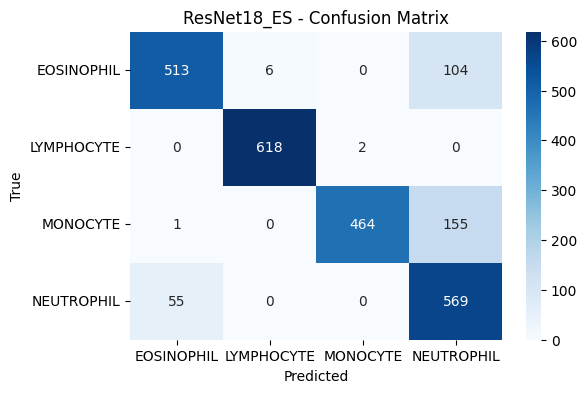

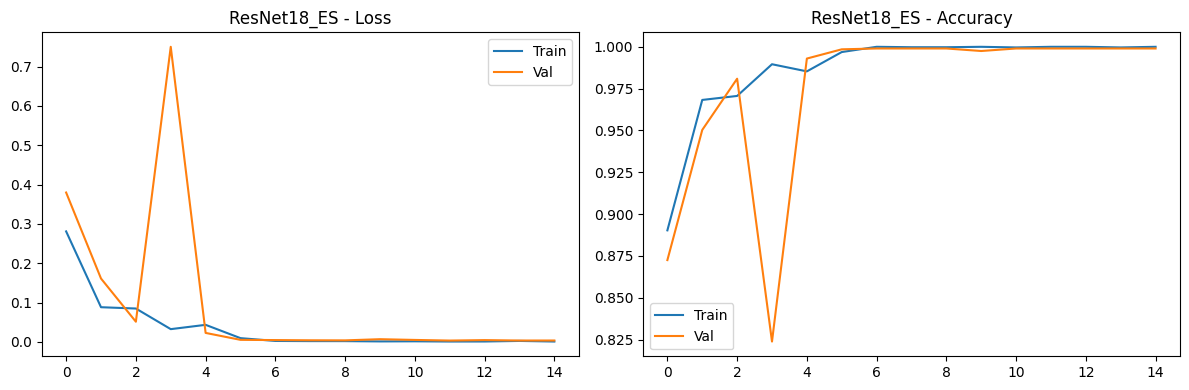

ResNet18_ES - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.90      0.82      0.86       623
  LYMPHOCYTE       0.99      1.00      0.99       620
    MONOCYTE       1.00      0.75      0.85       620
  NEUTROPHIL       0.69      0.91      0.78       624

    accuracy                           0.87      2487
   macro avg       0.89      0.87      0.87      2487
weighted avg       0.89      0.87      0.87      2487

Resnet18 с уввеличенными epochs и early stopping обучена и сохранена.


In [ ]:
resnet18_es = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # создание модели ResNet18
resnet18_es.fc = nn.Linear(resnet18_es.fc.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

resnet18_es_results = train_model_es(
    resnet18_es,
    "ResNet18_ES",
    train_loader,
    val_loader,
    test_loader,
    epochs=20,
    lr=1e-3,
    patience=3 # количество эпох для ранней остановки
)

torch.save(resnet18_es.state_dict(), "outputs/resnet18_es.pth") # сохранение модели
print("Resnet18 с уввеличенными epochs и early stopping обучена и сохранена.")

Увеличение числа эпох с ранней остановкой принесло прирост: Accuracy 0.8701 против baseline 0.8544 (+1.57%). Модель остановилась на эпохе 15 из 20. Характерный всплеск val loss на эпохе 4 (до 0.38) — тот же артефакт, что в hypothesis_2, — после которого модель стабилизировалась. Early stopping предотвратил переобучение в поздних эпохах.

Обучение модели Swin-T с большим количеством эпох и Early Stopping

Epoch 1/20 - Train Loss: 0.4637, Train Acc: 0.8151, Val Loss: 0.0739, Val Acc: 0.9724, Val Bal Acc: 0.9725, Val F1: 0.9724
Epoch 2/20 - Train Loss: 0.1050, Train Acc: 0.9643, Val Loss: 0.0442, Val Acc: 0.9864, Val Bal Acc: 0.9865, Val F1: 0.9865
Epoch 3/20 - Train Loss: 0.0515, Train Acc: 0.9849, Val Loss: 0.0225, Val Acc: 0.9920, Val Bal Acc: 0.9920, Val F1: 0.9920
Epoch 4/20 - Train Loss: 0.0387, Train Acc: 0.9882, Val Loss: 0.0136, Val Acc: 0.9965, Val Bal Acc: 0.9965, Val F1: 0.9965
Epoch 5/20 - Train Loss: 0.0286, Train Acc: 0.9908, Val Loss: 0.0158, Val Acc: 0.9960, Val Bal Acc: 0.9960, Val F1: 0.9960
Epoch 6/20 - Train Loss: 0.0134, Train Acc: 0.9967, Val Loss: 0.0088, Val Acc: 0.9970, Val Bal Acc: 0.9970, Val F1: 0.9970
Epoch 7/20 - Train Loss: 0.0129, Train Acc: 0.9971, Val Loss: 0.0069, Val Acc: 0.9975, Val Bal Acc: 0.9975, Val F1: 0.9975
Epoch 8/20 - Train Loss: 0.0119, Train Acc: 0.9979, Val Loss: 0.0054, Val Acc: 0.9980, Val Bal Acc: 0.9980, Val F1: 0.9980
Epoch 9/20 - Tra

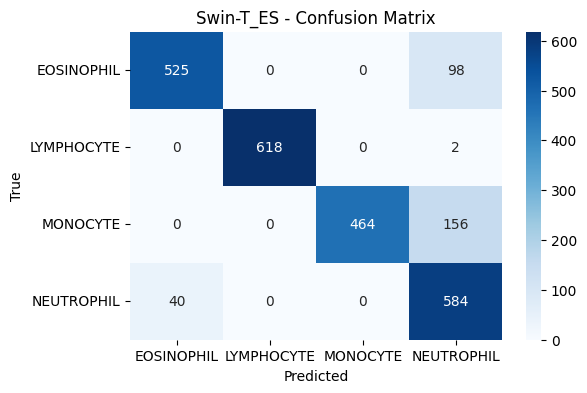

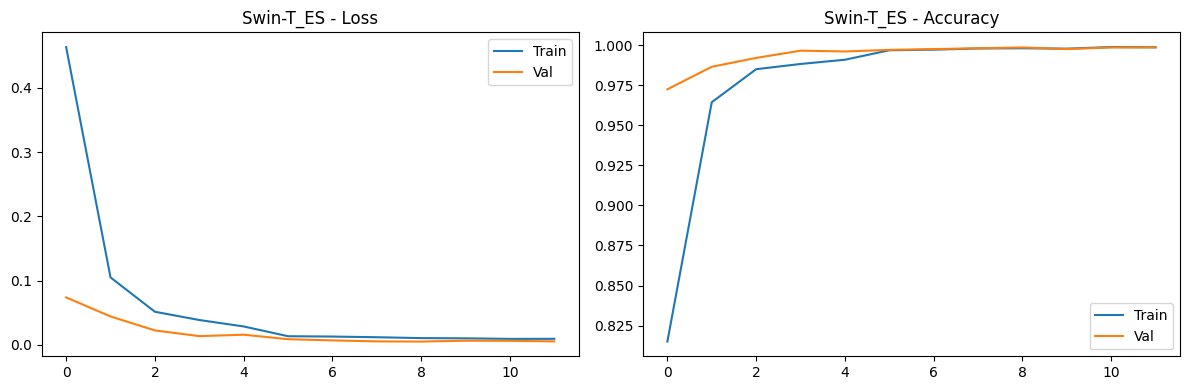

Swin-T_ES - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.93      0.84      0.88       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.70      0.94      0.80       624

    accuracy                           0.88      2487
   macro avg       0.91      0.88      0.88      2487
weighted avg       0.91      0.88      0.88      2487

Swin-T с уввеличенными epochs и early stopping обучена и сохранена.


In [ ]:
swin_es = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1) # создание модели Swin-T
swin_es.head = nn.Linear(swin_es.head.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

swin_es_results = train_model_es(
    swin_es,
    "Swin-T_ES",
    train_loader,
    val_loader,
    test_loader,
    epochs=20,
    lr=2e-5,
    patience=3
)

torch.save(swin_es.state_dict(), "outputs/swin_es.pth") # сохранение модели
print("Swin-T с уввеличенными epochs и early stopping обучена и сохранена.")

Незначительный прирост: Accuracy 0.8810 против 0.8802 (+0.08%). Остановка на эпохе 12. Гипотеза для Swin-T не подтвердилась значимым образом. Swin-T благодаря сильным предобученным весам практически достигает оптимума уже за 10 эпох, поэтому ни дополнительные эпохи, ни early stopping не дают существенного выигрыша.

Гипотеза частично подтвердилась — только для ResNet18. Больше эпох и ранняя остановка помогают моделям, которые ещё не успели сойтись за стандартные 10 эпох.